In [1]:
# ALWAYS RUN THIS FIRST!
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


NOTEBOOK_DIR = Path("/rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest")
os.chdir(NOTEBOOK_DIR)
sys.path.insert(0, str(NOTEBOOK_DIR))

print(f"✅ Working directory: {os.getcwd()}")

✅ Working directory: /rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest


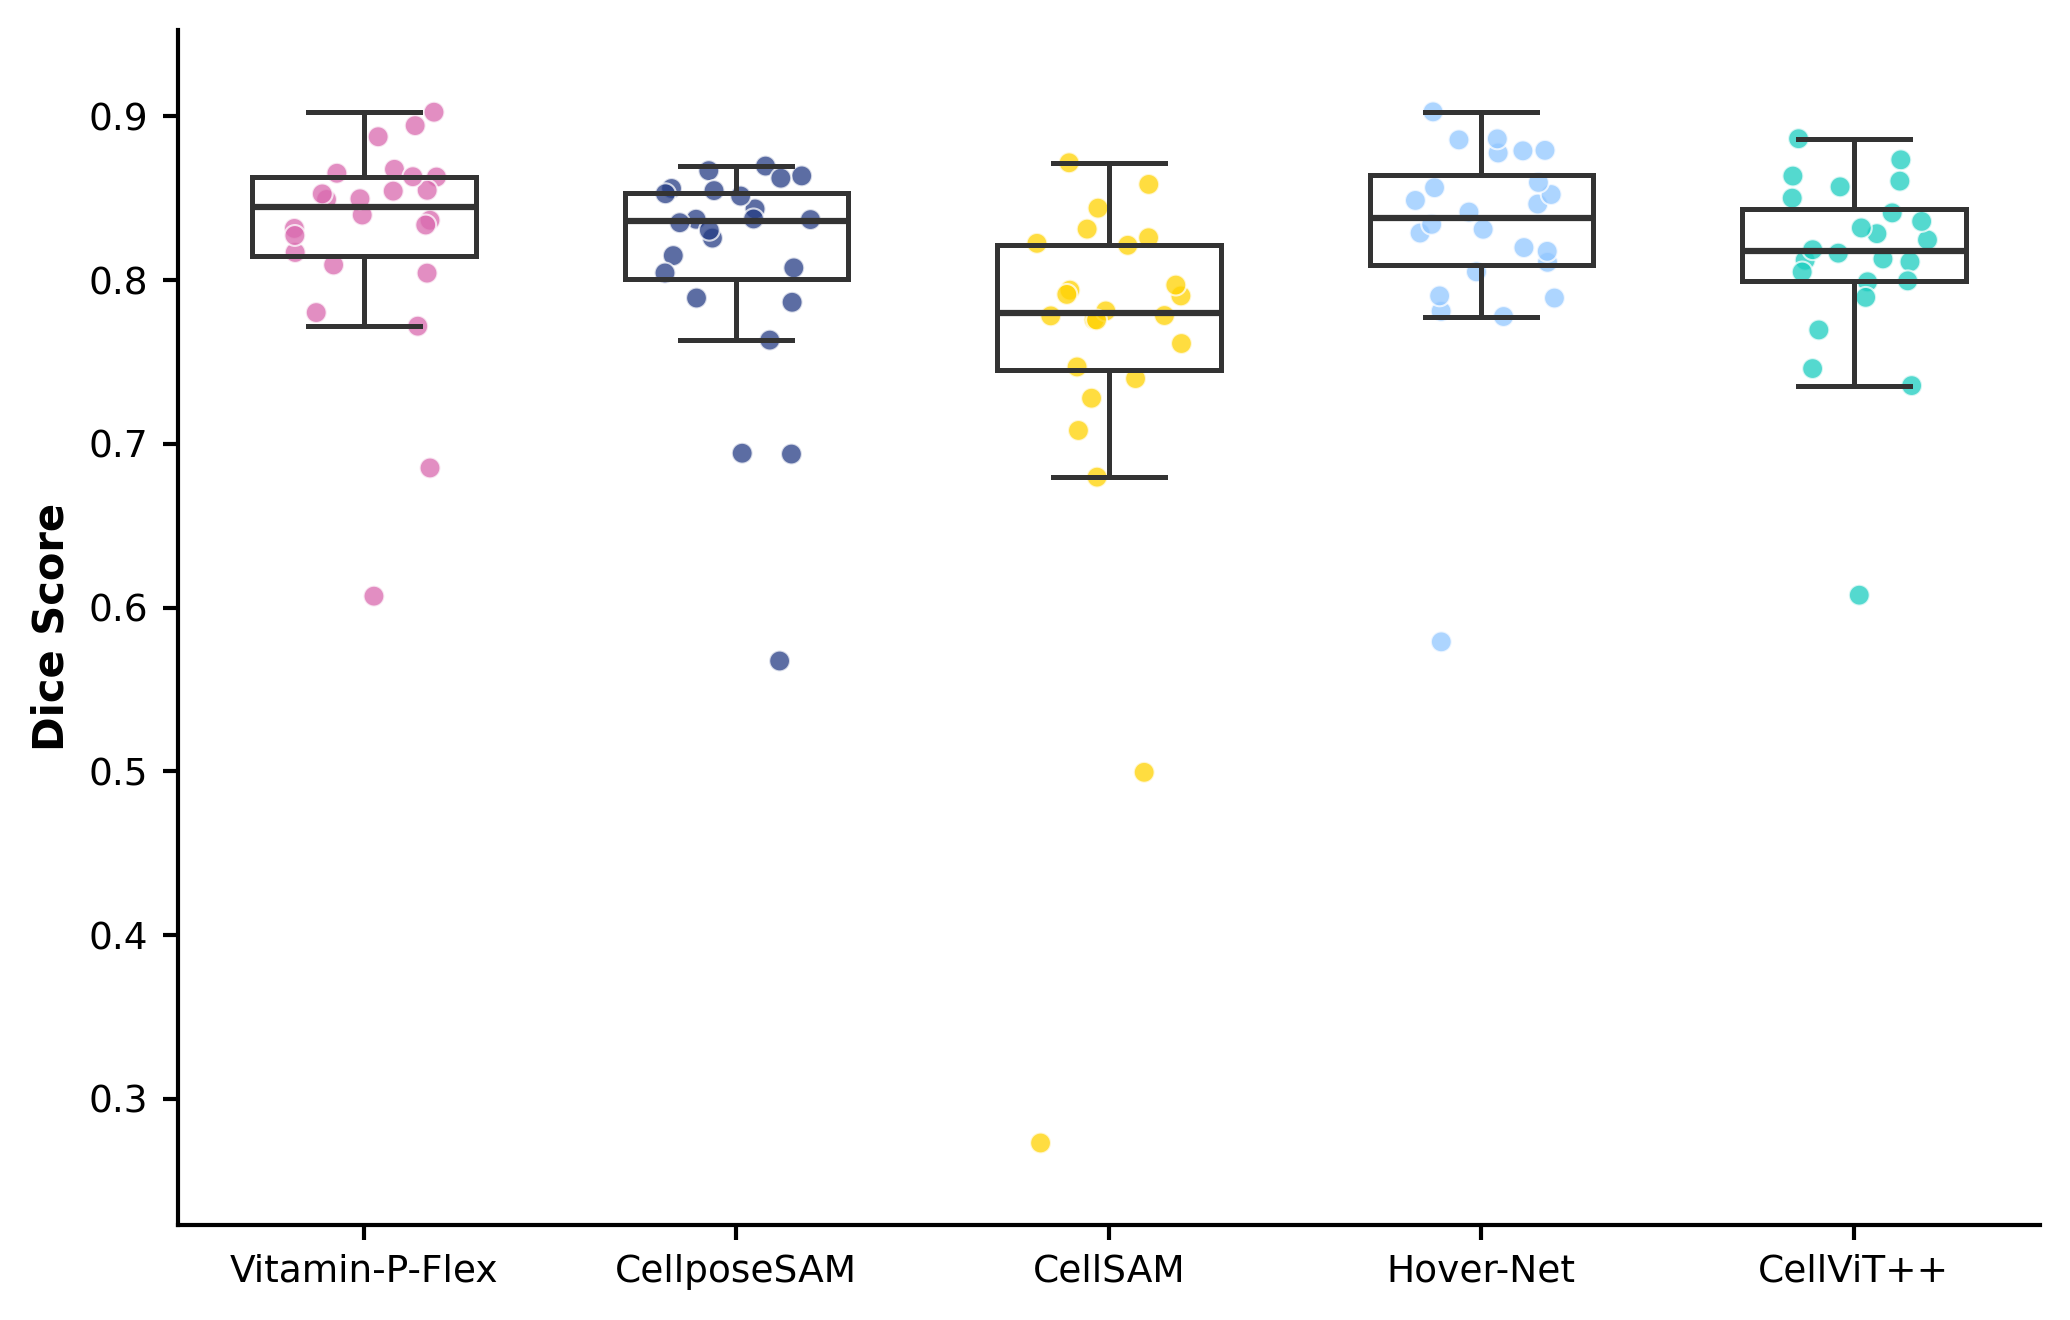

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

vitaminp_dice = [0.8493, 0.8398, 0.8527, 0.8630, 0.8366, 0.8169, 0.8677, 0.8549,
                 0.7802, 0.6070, 0.8337, 0.8316, 0.8544, 0.8093, 0.8043, 0.9026,
                 0.6853, 0.8497, 0.7719, 0.8944, 0.8653, 0.8632, 0.8273, 0.8876]

cellposesam_dice = [0.8372, 0.8351, 0.8150, 0.8697, 0.8257, 0.7634, 0.8560, 0.8669,
                    0.6943, 0.5674, 0.8305, 0.8435, 0.8075, 0.8374, 0.7891, 0.8528,
                    0.6938, 0.8044, 0.7865, 0.8514, 0.8637, 0.8623, 0.8370, 0.8547]

cellsam_dice = [0.8259, 0.7758, 0.7812, 0.8213, 0.7784, 0.7904, 0.8585, 0.7757,
                0.6797, 0.4994, 0.7939, 0.7782, 0.8312, 0.7470, 0.7082, 0.8717,
                0.2730, 0.8225, 0.7613, 0.8440, 0.7279, 0.7399, 0.7913, 0.7970]

hovernet_dice = [0.8199, 0.8288, 0.8416, 0.8465, 0.8109, 0.8051, 0.8777, 0.8341,
                 0.7891, 0.5791, 0.8176, 0.7778, 0.8863, 0.8311, 0.7810, 0.9028,
                 0.7904, 0.8565, 0.8790, 0.8857, 0.8487, 0.8523, 0.8597, 0.8793]

cellvit_dice = [0.8246, 0.8122, 0.8165, 0.8411, 0.8130, 0.8050, 0.8735, 0.8186,
                0.7460, 0.6076, 0.7990, 0.7895, 0.8636, 0.8112, 0.7696, 0.8864,
                0.7356, 0.8359, 0.7996, 0.8605, 0.8284, 0.8319, 0.8501, 0.8570]

samples = ['MOS001','MOS002','MOS003','MOS004','MOS008','MOS010','MOS014','MOS015',
           'MOS027','MOS033','MOS034','MOS042','MOS057','MOS058','MOS060','MOS061',
           'MOS064','MOS067','MOS078','MOS082','MOS084','MOS086','MOS099','MOS106']

# Updated the model names here
df = pd.DataFrame({
    'Sample': samples * 5,
    'dice': vitaminp_dice + cellposesam_dice + cellsam_dice + hovernet_dice + cellvit_dice,
    'Model': ['Vitamin-P-Flex'] * 24 + ['CellposeSAM'] * 24 + ['CellSAM'] * 24 + ['Hover-Net'] * 24 + ['CellViT++'] * 24
})

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 1.0,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)

# Custom color mapping updated here
colors = {
    'Vitamin-P-Flex': '#d969ae',
    'CellSAM':        '#ffd200',
    'CellposeSAM':    '#253c84',
    'Hover-Net':      '#92c7ff',
    'CellViT++':      '#1bcdc0'
}

order = ['Vitamin-P-Flex', 'CellposeSAM', 'CellSAM', 'Hover-Net', 'CellViT++']

# Boxplot skeleton
sns.boxplot(
    data=df, x='Model', y='dice', ax=ax,
    order=order,
    boxprops={'facecolor': 'none', 'linewidth': 1.2, 'edgecolor': '#333333'},
    medianprops={'linewidth': 1.5, 'color': '#333333'},
    whiskerprops={'linewidth': 1.2, 'color': '#333333'},
    capprops={'linewidth': 1.2, 'color': '#333333'},
    flierprops={'marker': ''},
    width=0.6,
    zorder=10
)

# Stripplot with colors
sns.stripplot(
    data=df, x='Model', y='dice', ax=ax,
    order=order,
    hue='Model', palette=colors, legend=False,
    alpha=0.75, size=5, jitter=0.2, linewidth=0.5, edgecolor='white',
    zorder=5
)

# Labeling and bounding boxes dynamically
ax.set_ylabel('Dice Score', fontweight='bold')
ax.set_xlabel('')

min_val = df['dice'].min()
max_val = df['dice'].max()
ax.set_ylim(min_val - 0.05, max_val + 0.05)

plt.tight_layout()
plt.show()

# Use this to save out for your paper:
# plt.savefig('dice_scores_updated.pdf', bbox_inches='tight', transparent=True)

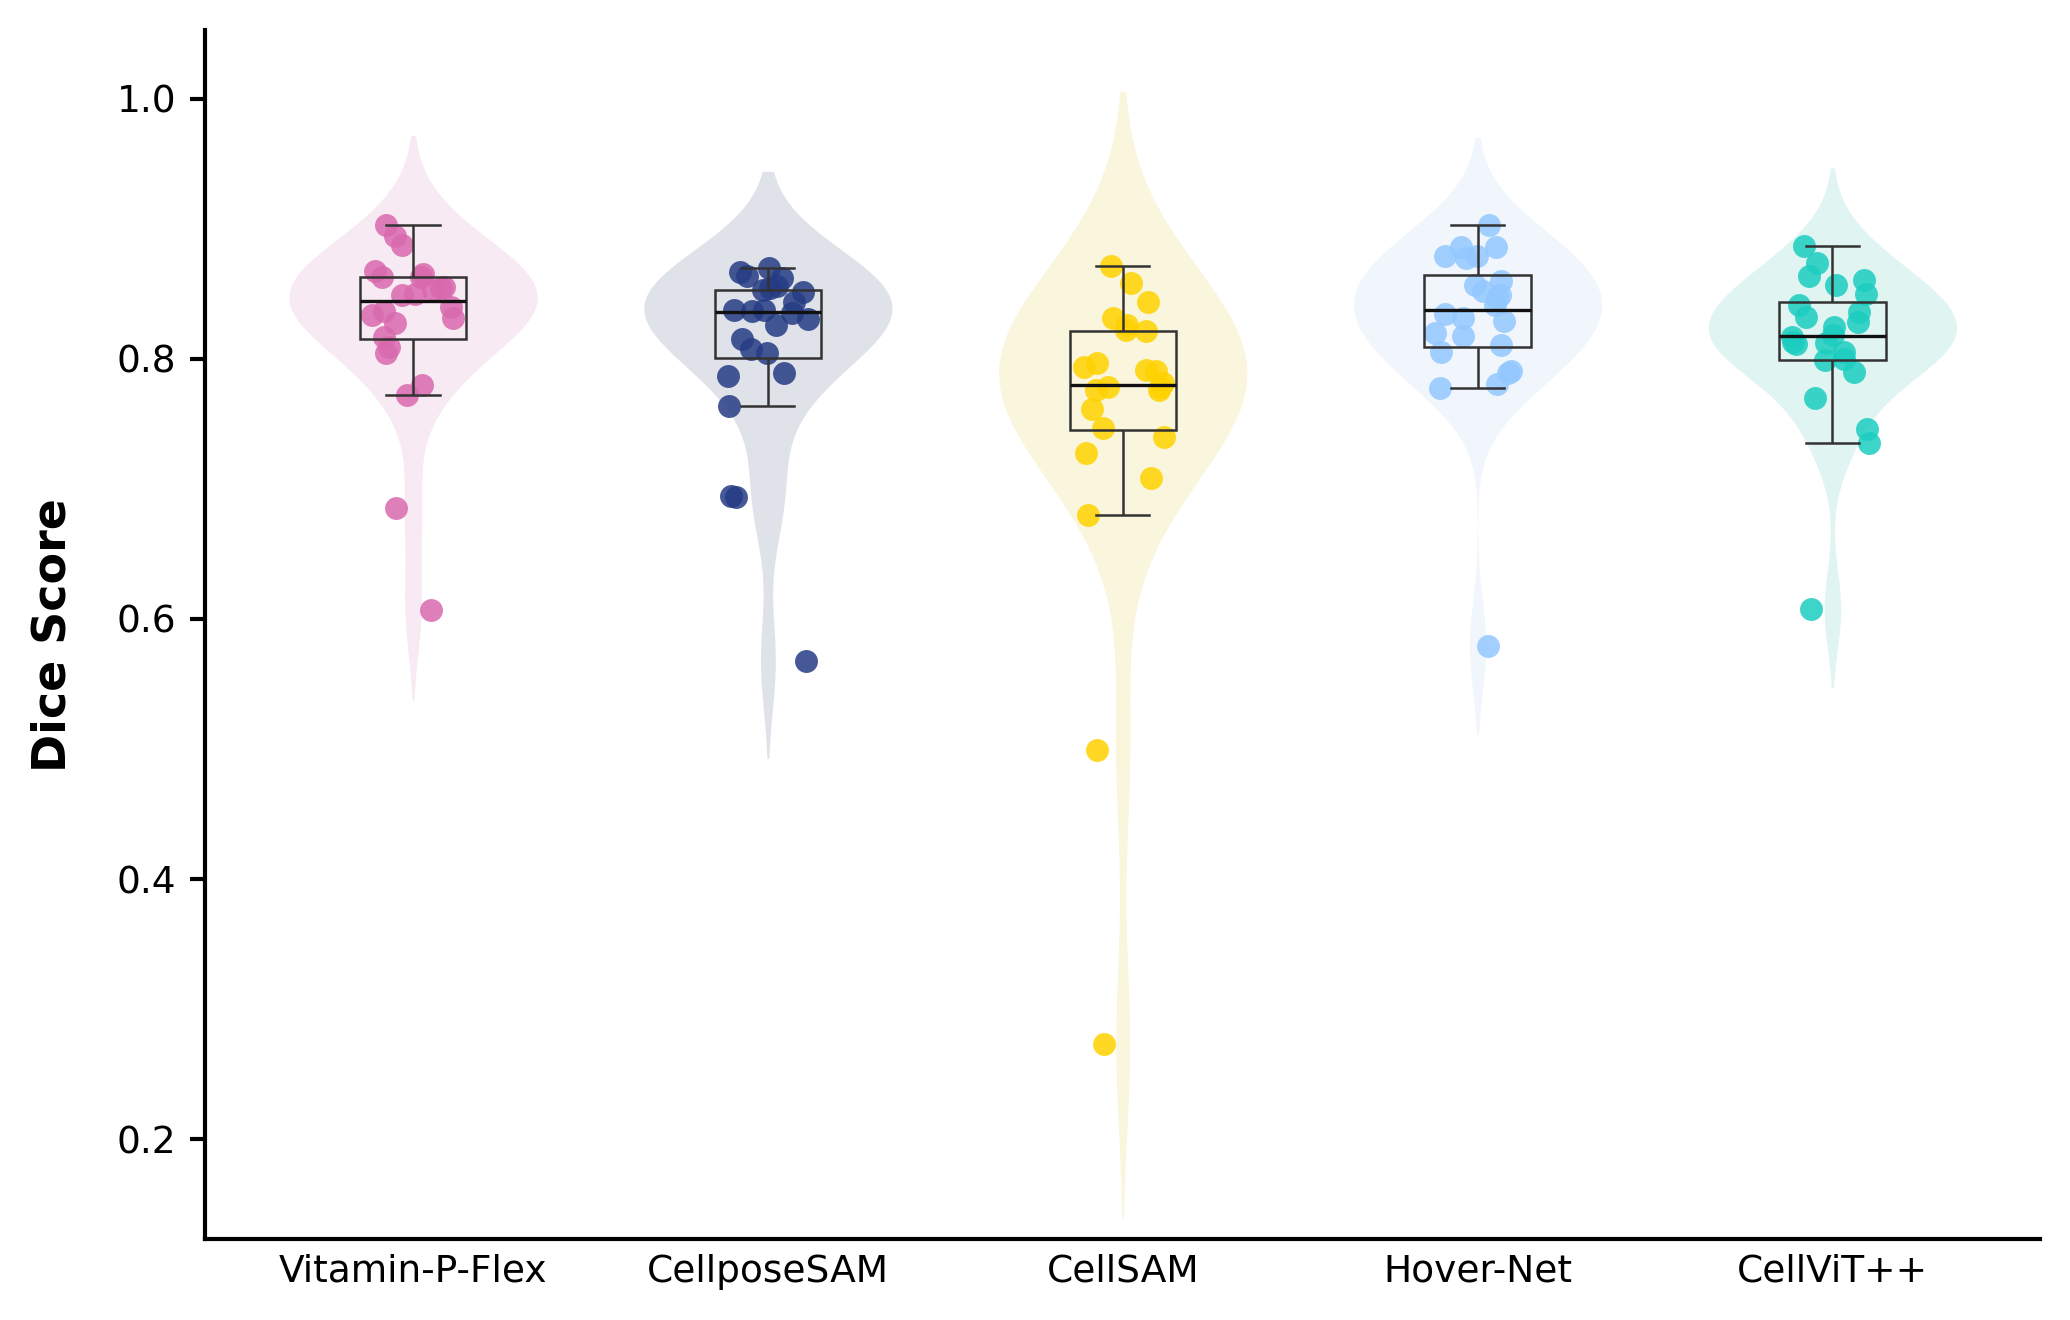

Saved.


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# ---------------------------------------------------------
# SETTINGS FOR ADOBE ILLUSTRATOR COMPATIBILITY
# ---------------------------------------------------------
plt.rcParams['pdf.fonttype'] = 42  # Embeds fonts as TrueType
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

# --- Data Definition ---
vitaminp_dice = [0.8493, 0.8398, 0.8527, 0.8630, 0.8366, 0.8169, 0.8677, 0.8549,
                 0.7802, 0.6070, 0.8337, 0.8316, 0.8544, 0.8093, 0.8043, 0.9026,
                 0.6853, 0.8497, 0.7719, 0.8944, 0.8653, 0.8632, 0.8273, 0.8876]

cellposesam_dice = [0.8372, 0.8351, 0.8150, 0.8697, 0.8257, 0.7634, 0.8560, 0.8669,
                    0.6943, 0.5674, 0.8305, 0.8435, 0.8075, 0.8374, 0.7891, 0.8528,
                    0.6938, 0.8044, 0.7865, 0.8514, 0.8637, 0.8623, 0.8370, 0.8547]

cellsam_dice = [0.8259, 0.7758, 0.7812, 0.8213, 0.7784, 0.7904, 0.8585, 0.7757,
                0.6797, 0.4994, 0.7939, 0.7782, 0.8312, 0.7470, 0.7082, 0.8717,
                0.2730, 0.8225, 0.7613, 0.8440, 0.7279, 0.7399, 0.7913, 0.7970]

hovernet_dice = [0.8199, 0.8288, 0.8416, 0.8465, 0.8109, 0.8051, 0.8777, 0.8341,
                 0.7891, 0.5791, 0.8176, 0.7778, 0.8863, 0.8311, 0.7810, 0.9028,
                 0.7904, 0.8565, 0.8790, 0.8857, 0.8487, 0.8523, 0.8597, 0.8793]

cellvit_dice = [0.8246, 0.8122, 0.8165, 0.8411, 0.8130, 0.8050, 0.8735, 0.8186,
                0.7460, 0.6076, 0.7990, 0.7895, 0.8636, 0.8112, 0.7696, 0.8864,
                0.7356, 0.8359, 0.7996, 0.8605, 0.8284, 0.8319, 0.8501, 0.8570]

samples = ['MOS001','MOS002','MOS003','MOS004','MOS008','MOS010','MOS014','MOS015',
           'MOS027','MOS033','MOS034','MOS042','MOS057','MOS058','MOS060','MOS061',
           'MOS064','MOS067','MOS078','MOS082','MOS084','MOS086','MOS099','MOS106']

df = pd.DataFrame({
    'Sample': samples * 5,
    'dice': vitaminp_dice + cellposesam_dice + cellsam_dice + hovernet_dice + cellvit_dice,
    'Model': ['Vitamin-P-Flex'] * 24 + ['CellposeSAM'] * 24 + ['CellSAM'] * 24 + ['Hover-Net'] * 24 + ['CellViT++'] * 24
})

# --- Plot Aesthetics (Nature Guidelines) ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 1.0,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)

colors = {
    'Vitamin-P-Flex': '#d969ae',
    'CellposeSAM':    '#253c84',
    'CellSAM':        '#ffd200',
    'Hover-Net':      '#92c7ff',
    'CellViT++':      '#1bcdc0'
}

order = ['Vitamin-P-Flex', 'CellposeSAM', 'CellSAM', 'Hover-Net', 'CellViT++']

# 1. Transparent Violin Plot
sns.violinplot(
    data=df, x='Model', y='dice', ax=ax,
    order=order, palette=colors, hue='Model', legend=False,
    inner=None, alpha=0.15, linewidth=0, width=0.7, zorder=1
)

# 2. Refined Boxplot Skeleton
sns.boxplot(
    data=df, x='Model', y='dice', ax=ax,
    order=order,
    boxprops={'facecolor': 'none', 'linewidth': 0.6, 'edgecolor': '#333333'},
    medianprops={'linewidth': 0.8, 'color': '#111111'},
    whiskerprops={'linewidth': 0.6, 'color': '#333333'},
    capprops={'linewidth': 0.6, 'color': '#333333'},
    flierprops={'marker': ''},
    width=0.3,
    zorder=10
)

# 3. Draw dots individually per point using ax.plot() so each dot is a
#    separate path object in the PDF → fully selectable in Adobe Illustrator.
#    We replicate jitter manually with a fixed seed for reproducibility.
np.random.seed(42)
jitter_strength = 0.12

for i, model in enumerate(order):
    subset = df[df['Model'] == model]['dice'].values
    color = colors[model]
    jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(subset))
    x_positions = i + jitter

    for x_pos, y_val in zip(x_positions, subset):
        ax.plot(
            x_pos, y_val,
            marker='o',
            markersize=5.5,
            color=color,
            alpha=0.85,
            markeredgewidth=0,   # No stroke
            linestyle='none',
            zorder=5
        )

# --- Labeling and Bounds ---
ax.set_ylabel('Dice Score', fontweight='bold', fontsize=11, labelpad=10)
ax.set_xlabel('')
ax.tick_params(axis='x', length=0)
plt.xticks(fontweight='medium')

min_val = df['dice'].min()
max_val = df['dice'].max()
ax.set_ylim(min_val - 0.15, max_val + 0.15)

plt.tight_layout()
plt.savefig('ds_nuclei.pdf', format='pdf', bbox_inches='tight', transparent=True)
plt.show()
print("Saved.")